# Harmonic Math Sandbox (Tempo Class)
Testing the $O(1)$ logarithmic modulo space tracking in a simplified environment without complex jailbreak triggers.

In [4]:
import numpy as np
import time
from collections import deque
import warnings
warnings.filterwarnings('ignore')

import sys
import os
sys.path.append(os.path.abspath('../..'))
import core.Listener as ListenerModule
from IPython.display import display, clear_output

def default_infos():
    return {
        "startServer"     : False ,
        "useMicrophone"   : True  ,
        "HARDWARE_MODE"   : "simulation",
        "onRaspberry"     : False  ,
        "printTimeOfCalculation" : False ,
        "printModesDetails"      : True ,
        "printMicrophoneDetails" : False ,
        "printAppDetails"        : False ,
        "printAsservmentDetails" : False ,
        "printConfigurationLoads": False ,
        "printConfigChanges"     : False ,
        "modesToPrintDetails"    : ["PSG"]
    }



In [5]:
import librosa
import numpy as np
import os
import json

root        = '../../assets/musics/mp3_files/'
DB_PATH     = os.path.join(root, 'bpm_database.json')

# Load the BPM database
with open(DB_PATH, 'r', encoding='utf-8') as _f:
    _bpm_db = json.load(_f)

# Select songs to test — edit this list freely.
# Only names that exist in bpm_database.json will work.
TEST_SONGS = [
    'Palladium',
    'Pumped Up Kicks',
    'Nobody Rules the Streets',
    'Another One Bites The Dust - Remastered 2011',
    "Stayin' Alive - From _Saturday Night Fever_ Soundtrack",
    'Boogie Wonderland',
    'Roxanne - Remastered 2003',
    'September',
    '01-Plastic-People',
    "Djon maya maï (feat. Victor Démé)",
    "Feeling Good",
    "Heroes",
    "Money For Nothing_1"

]

SONGS      = [(name, _bpm_db[name]['bpm']) for name in TEST_SONGS if name in _bpm_db]
song_files = [root + name + '.mp3' for name, _ in SONGS]
real_bpms  = [bpm for _, bpm in SONGS]
song_names = [name for name, _ in SONGS]

librosa_dir = os.path.join(root, 'librosa')
os.makedirs(librosa_dir, exist_ok=True)

y_list = []
for f in song_files:
    basename  = os.path.basename(f)
    save_path = os.path.join(librosa_dir, f'{basename}.npz')
    if os.path.exists(save_path):
        data = np.load(save_path, allow_pickle=True)
        y = data['y']
    else:
        y, _ = librosa.load(f, sr=44100)
        np.savez(save_path, y=y, sr=44100)
    y_list.append(y)



In [6]:
class Robust_Simulated_Microphone:
    def __init__(self, y_full_array, bandValues, infos):
        self.bandValues = bandValues
        self.nb_of_fft_band = len(self.bandValues)
        self.sample_rate = 44100
        self.buffer_size = 1024 
        self.audio_data = np.zeros(self.buffer_size)
        self.full_audio = y_full_array
        self.total_samples = len(self.full_audio)
        self.current_pos = 0
        fft_size = self.buffer_size // 2 + 1
        self.weight_matrix = np.zeros((self.nb_of_fft_band, fft_size))
        
        def hz_to_mel(f): return 2595 * np.log10(1 + f / 700.0)
        def mel_to_hz(m): return 700 * (10**(m / 2595.0) - 1)
        
        lower_mel = hz_to_mel(20)
        upper_mel = hz_to_mel(20000)
        mel_points = np.linspace(lower_mel, upper_mel, self.nb_of_fft_band + 2)
        hz_points = mel_to_hz(mel_points)
        bin_points = np.floor((self.buffer_size + 1) * hz_points / self.sample_rate).astype(int)
        
        for i in range(self.nb_of_fft_band):
            start = min(bin_points[i], fft_size - 1)
            mid = min(bin_points[i + 1], fft_size - 1)
            end = min(bin_points[i + 2], fft_size - 1)
            if mid > start:
                self.weight_matrix[i, start:mid] = np.linspace(0, 1, mid - start, endpoint=False)
            if end > mid:
                self.weight_matrix[i, mid:end] = np.linspace(1, 0, end - mid, endpoint=False)
            band_sum = np.sum(self.weight_matrix[i, :])
            if band_sum > 0:
                self.weight_matrix[i, :] /= band_sum
                
        self.raw_fft_history = None

    def pop_chunk(self, chunk_size=1024):
        if self.current_pos + chunk_size > self.total_samples:
            return False 
        incoming = self.full_audio[self.current_pos : self.current_pos + chunk_size]
        self.current_pos += chunk_size
        self.audio_data = np.roll(self.audio_data, -chunk_size)
        self.audio_data[-chunk_size:] = incoming
        return True

    def calculate_fft(self):
        windowed_data = self.audio_data * np.hanning(self.buffer_size)
        fft_result = np.abs(np.fft.rfft(windowed_data))
        scale = 150.0 / (self.buffer_size / 1024.0)
        mel_bands = np.dot(self.weight_matrix, fft_result) * scale
        for i in range(self.nb_of_fft_band):
            self.bandValues[i] = int(mel_bands[i])
        self.raw_fft_history = fft_result



In [7]:
# THE HARMONIC MATH CORE (SIMPLIFIED)
def bpm_to_class(bpm):
    '''Map BPM to a float in [0, 1) based on octave'''
    return np.log2(bpm / 60.0) % 1.0

def class_to_bpm_candidates(bpm_class):
    '''Returns the most common harmonic multipliers for a given class'''
    base_bpm = 60.0 * (2 ** bpm_class)
    return [
        base_bpm * 0.5,    # e.g., 50
        base_bpm * 0.75,   # e.g., 75
        base_bpm * 1.0,    # e.g., 100
        base_bpm * 1.5,    # e.g., 150
        base_bpm * 2.0     # e.g., 200
    ]

def tempo_class_distance(f1, f2):
    '''Shortest circular distance on [0, 1)'''
    d = abs(f1 - f2)
    return min(d, 1.0 - d)

def harmonic_alignment(current_class, long_term_class):
    '''Checks straight octaves AND perfect fifths (1.5x) to safely align and find distance'''
    shift = np.log2(1.5) # approx 0.58496
    d_oct = tempo_class_distance(current_class, long_term_class)
    d_fifth_up = tempo_class_distance(current_class, (long_term_class + shift) % 1.0)
    d_fifth_down = tempo_class_distance(current_class, (long_term_class - shift) % 1.0)
    
    min_d = min(d_oct, d_fifth_up, d_fifth_down)
    
    if min_d == d_oct:
        aligned_class = current_class
    elif min_d == d_fifth_up:
        aligned_class = (current_class - shift) % 1.0
    else:
        aligned_class = (current_class + shift) % 1.0
        
    return min_d, aligned_class



In [8]:
# THE TEMPLATE BANK (O(1) Precomputed Pearson Correlation)
class FastTemplateBank:
    def __init__(self, btrack_fps=60.0, odf_size=300):
        self.btrack_fps = btrack_fps
        self.odf_size = odf_size
        self.templates = {}
        
        buffer_indices = np.arange(self.odf_size)
        self.const_part = buffer_indices - (self.odf_size - 1)
        
    def get_template(self, bpm_val):
        if bpm_val in self.templates:
            return self.templates[bpm_val]
            
        tau_val = 60.0 * self.btrack_fps / bpm_val
        p_max = int(np.ceil(tau_val))
        
        p_arr = np.arange(p_max)[:, None]
        phase_float = (self.const_part[None, :] + p_arr) % tau_val
        norm_phi = phase_float / tau_val 
        
        # Sharp Triangle Pulse
        beat_dist = np.minimum(norm_phi, 1.0 - norm_phi)
        template_vals = np.full((p_max, self.odf_size), -1.0)
        mask_beat = beat_dist < 0.1
        template_vals[mask_beat] = 1.0 - (beat_dist[mask_beat] / 0.1)
        
        template_mean = np.mean(template_vals, axis=1, keepdims=True)
        template_centered = template_vals - template_mean
        template_std = np.sqrt(np.sum(template_centered**2, axis=1)) + 1e-6
        
        # Pre-normalized template for rapid matrix multiplication
        normalized_template = template_centered / template_std[:, None]
        self.templates[bpm_val] = normalized_template
        return normalized_template

# Global Bank Instance
template_bank = FastTemplateBank()

# THE CANDIDATE EVALUATOR (HEAVY JUDGE)
def evaluate_specific_bpms(odf_buffer, candidate_bpms, **kwargs):
    odf_size = len(odf_buffer)
    decay_curve = np.exp(-1.5 * np.linspace(1.0, 0.0, odf_size))
    weighted_buffer = odf_buffer * decay_curve
    
    # Pre-compute zero-mean buffer for Pearson
    buffer_mean = np.mean(weighted_buffer)
    buffer_centered = weighted_buffer - buffer_mean
    buffer_std = np.sqrt(np.sum(buffer_centered**2)) + 1e-6
    
    best_score_pearson = -float('inf')
    best_bpm_pearson = candidate_bpms[0]
    
    for bpm_val in candidate_bpms:
        if not (40.0 <= bpm_val <= 190.0):
            continue
            
        normalized_template = template_bank.get_template(bpm_val)
        
        # O(1) Vectorized Pearson Correlation via Dot Product
        p_scores_pearson = (normalized_template @ buffer_centered) / buffer_std
        
        # --- STATIC HUMAN PRIOR (125.0) ---
        human_prior = 0.5 + 0.5 * np.exp(-0.5 * ((bpm_val - 125.0) / 40.0)**2)
        weighted_score = np.max(p_scores_pearson) * human_prior
        
        if weighted_score > best_score_pearson:
            best_score_pearson = weighted_score
            best_bpm_pearson = bpm_val
            
    return best_bpm_pearson, best_score_pearson


In [9]:
# THE INITIAL SWEEP (FAST SCOUT) - TRUE PEARSON O(1)
def class_based_phase_sweep(odf_buffer, class_evals, **kwargs):
    odf_size = len(odf_buffer)
    decay_curve = np.exp(-1.5 * np.linspace(1.0, 0.0, odf_size))
    weighted_buffer = odf_buffer * decay_curve
    
    buffer_mean = np.mean(weighted_buffer)
    buffer_centered = weighted_buffer - buffer_mean
    buffer_std = np.sqrt(np.sum(buffer_centered**2)) + 1e-6
    
    best_overall_score = -float('inf')
    best_overall_class = class_evals[0] % 1.0
    
    for class_val in class_evals:
        c = class_val % 1.0
        base_bpm = 60.0 * (2 ** c)
        eval_bpm = base_bpm if base_bpm >= 90.0 else base_bpm * 2.0
        
        normalized_template = template_bank.get_template(eval_bpm)
        p_scores = (normalized_template @ buffer_centered) / buffer_std
        
        # Human Prior injected into Fast Scout to fix Song 3 polyrhythms!
        human_prior = 0.5 + 0.5 * np.exp(-0.5 * ((eval_bpm - 125.0) / 40.0)**2)
        tau_max_score = np.max(p_scores) * human_prior
        
        if tau_max_score > best_overall_score:
            best_overall_score = tau_max_score
            best_overall_class = c
            
    return best_overall_class, best_overall_score


In [10]:
# =====================================================================
# FAKE LISTENER - replaces the full Listener stack for simulation speed
# Only runs the 3 cheap AudioIngestion functions we actually need:
#   - update_band_means_and_smoothed_values
#   - asserv_fft_bands
#   - asserv_total_power
# Skips AudioAnalyzer entirely (no BTrack, no detect_band_peaks)
# =====================================================================

class FakeListener:
    NB_BANDS = 8

    def __init__(self):
        n = self.NB_BANDS
        self.fft_band_values     = np.zeros(n)
        self.smoothed_fft_band_values = np.zeros(n)
        self.band_means          = np.zeros(n)
        self.band_mean_distances = np.zeros(n)
        self.band_proportion     = np.zeros(n)
        self.band_lm             = np.ones(n) * 100.0
        self.band_gm             = np.ones(n) * 100.0
        self.asserved_fft_band   = np.zeros(n)
        self.smoothed_total_power  = 0.0
        self.asserved_total_power  = 0.0
        self.total_power_lm        = 100.0
        self.total_power_gm        = 100.0
        # stub attributes the simulation may read
        self.bpm = 120.0

    def update(self, fps_ratio=1.0):
        self._update_band_means(fps_ratio)
        self._asserv_fft_bands(fps_ratio)
        self._asserv_total_power(fps_ratio)

    # ---- copied & vectorized from AudioIngestion ----

    def _update_band_means(self, fps_ratio):
        attack  = 0.2  ** fps_ratio
        release = 0.85 ** fps_ratio
        smoothing = np.where(self.fft_band_values > self.smoothed_fft_band_values, attack, release)
        self.smoothed_fft_band_values = np.where(
            self.smoothed_fft_band_values < 1,
            self.fft_band_values,
            smoothing * self.smoothed_fft_band_values + (1 - smoothing) * self.fft_band_values
        )
        self.smoothed_fft_band_values = np.maximum(self.smoothed_fft_band_values, 0)

        retention = 0.999 ** fps_ratio
        self.band_means = np.where(
            self.band_means < 1,
            self.smoothed_fft_band_values,
            retention * self.band_means + (1 - retention) * self.smoothed_fft_band_values
        )
        self.band_means = np.maximum(self.band_means, 0)

        distances_target = np.abs(self.smoothed_fft_band_values - self.band_means)
        self.band_mean_distances = np.where(
            self.band_mean_distances < 1,
            self.smoothed_fft_band_values / 2.0,
            retention * self.band_mean_distances + (1 - retention) * distances_target
        )

        total = np.sum(self.smoothed_fft_band_values)
        if total > 0:
            self.band_proportion = self.smoothed_fft_band_values / total
        else:
            self.band_proportion.fill(0.0)

    def _asserv_fft_bands(self, fps_ratio):
        for i in range(self.NB_BANDS):
            sv = self.smoothed_fft_band_values[i]
            if sv >= self.band_lm[i]:
                self.band_lm[i] = sv
            else:
                self.band_lm[i] *= 0.9995 ** fps_ratio
            if sv >= self.band_gm[i]:
                self.band_gm[i] = 1.01 * sv
            else:
                self.band_gm[i] *= 1 + (0.005 * fps_ratio) * (self.band_lm[i] / max(0.001, self.band_gm[i]) - 0.9)
            self.asserved_fft_band[i] += min(1.0, 0.4 * fps_ratio) * (sv / self.band_gm[i] - self.asserved_fft_band[i])

    def _asserv_total_power(self, fps_ratio):
        instant = np.sum(self.fft_band_values)
        r = 0.5 ** fps_ratio
        self.smoothed_total_power = r * self.smoothed_total_power + (1 - r) * instant
        if self.smoothed_total_power > self.total_power_lm:
            self.total_power_lm = self.smoothed_total_power
        else:
            self.total_power_lm *= 0.9998 ** fps_ratio
        if self.smoothed_total_power > self.total_power_gm:
            self.total_power_gm = 1.01 * self.smoothed_total_power
        else:
            self.total_power_gm *= 1 + (0.005 * fps_ratio) * (self.total_power_lm / self.total_power_gm - 0.9)
        self.asserved_total_power += min(1.0, 0.4 * fps_ratio) * (self.smoothed_total_power / self.total_power_gm - self.asserved_total_power)

print('FakeListener defined.')


FakeListener defined.


## Beat Tracking Evaluation (Phase Flywheel)
This section overrides the standard simulation to include a Phase Flywheel. It outputs discrete beat timestamps which are then evaluated against `librosa`'s offline beat tracker using `mir_eval`.

In [11]:
import mir_eval
import numpy as np

def simulate_audio_ingestion(y, sr=44100):
    SIMULATED_FPS = 60.0
    CHUNK_SIZE = int(sr / SIMULATED_FPS)
    BUFFER_SIZE = 1024
    
    # FakeListener properties
    NB_BANDS = 32 
    audio_buffer = np.zeros(BUFFER_SIZE)
    fft_size = BUFFER_SIZE // 2 + 1
    
    # Setup Mel filterbank exactly as FakeListener
    def hz_to_mel(f): return 2595 * np.log10(1 + f / 700.0)
    def mel_to_hz(m): return 700 * (10**(m / 2595.0) - 1)
    lower_mel = hz_to_mel(20);  upper_mel = hz_to_mel(20000)
    mel_pts   = np.linspace(lower_mel, upper_mel, NB_BANDS + 2)
    hz_pts    = mel_to_hz(mel_pts)
    bin_pts   = np.floor((BUFFER_SIZE + 1) * hz_pts / sr).astype(int)
    W = np.zeros((NB_BANDS, fft_size))
    for i in range(NB_BANDS):
        s, m, e = (min(bin_pts[i+k], fft_size-1) for k in range(3))
        if m > s: W[i, s:m] = np.linspace(0, 1, m-s, endpoint=False)
        if e > m: W[i, m:e] = np.linspace(1, 0, e-m, endpoint=False)
        tot = W[i].sum()
        if tot > 0: W[i] /= tot
    hanning = np.hanning(BUFFER_SIZE)
    
    pos = 0
    odf = []
    prev_bands = np.zeros(NB_BANDS)
    
    while pos + CHUNK_SIZE <= len(y):
        chunk = y[pos: pos + CHUNK_SIZE]
        pos += CHUNK_SIZE
        audio_buffer = np.roll(audio_buffer, -CHUNK_SIZE)
        audio_buffer[-CHUNK_SIZE:] = chunk
        fft_result = np.abs(np.fft.rfft(audio_buffer * hanning))
        mel = np.dot(W, fft_result) * (150.0 / (BUFFER_SIZE / 1024.0))
        
        current_bands = mel.astype(int)
        flux_bands = np.maximum(0, current_bands - prev_bands)
        prev_bands = current_bands
        custom_flux = 2.0 * np.sum(flux_bands[0:2]) + 0.5 * np.sum(flux_bands[-2:])
        
        odf.append(custom_flux)
        
    return {'odf': np.array(odf)}



In [12]:
def run_simulation_with_beats(audio_features):
    """
    Runs the full tracker simulation over ODF and accumulates phase to emit beat timestamps.
    """
    listener = FakeListener()
    
    phase = 0.0
    beat_timestamps = []
    
    # History logs
    history_logs = {
        'time': [],
        'bpm': [],
        'phase': [],
        'long_term_class': [],
        'circular_dist': [],
        'log_bpm': [],
        'flywheel_status': []
    }
    
    SIMULATED_FPS = 60.0
    TIME_PER_FRAME = 1.0 / SIMULATED_FPS
    
    custom_odf_buffer = np.zeros(300)
    smoothed_flux = 0.0
    time_since_good_confidence = 0.0
    long_term_class = 0.0
    bpm_pearson = 120.0
    listener.bpm = 120.0
    
    for frame_idx, onset_val in enumerate(audio_features['odf']): 
        playhead_time = frame_idx * TIME_PER_FRAME
        time_since_good_confidence += TIME_PER_FRAME
        
        # Phase increment
        phase_increment = (listener.bpm / 60.0) * TIME_PER_FRAME
        phase += phase_increment
        
        if phase >= 1.0:
            beat_timestamps.append(playhead_time)
            phase -= 1.0
            
        # Process ODF
        custom_flux = onset_val
        custom_odf_buffer = np.roll(custom_odf_buffer, -1)
        custom_odf_buffer[-1] = custom_flux
        smoothed_flux = 0.95 * smoothed_flux + 0.05 * custom_flux
        is_peak = custom_flux > (smoothed_flux * 1.8 + 0.1)
        
        circular_dist = 0.0
        flywheel_status = 'coasting'
        
        if is_peak:
            if playhead_time < 5.0 or time_since_good_confidence > 3.0:
                class_evals = np.arange(0.0, 1.0, 0.01)
                is_strong_sweep = True
            else:
                class_evals = np.arange(long_term_class - 0.05, long_term_class + 0.05 + 0.001, 0.01)
                is_strong_sweep = False

            best_class, _ = class_based_phase_sweep(custom_odf_buffer, class_evals)
            min_d, aligned_class = harmonic_alignment(best_class, long_term_class)

            if is_strong_sweep:
                temp_ltc = aligned_class
            else:
                diff = (aligned_class - long_term_class + 0.5) % 1.0 - 0.5
                temp_ltc = (long_term_class + 0.1 * diff) % 1.0
            candidates = class_to_bpm_candidates(temp_ltc)

            bpm_pearson_raw, score_pearson = evaluate_specific_bpms(custom_odf_buffer, candidates)
            winning_class = bpm_to_class(bpm_pearson_raw)
            circular_dist = abs((winning_class - long_term_class + 0.5) % 1.0 - 0.5)
            
            if playhead_time < 5.0:
                required_threshold = 0.15
            else:
                if circular_dist > 0.1:
                    required_threshold = 0.23
                else:
                    required_threshold = 0.15
            
            if score_pearson >= required_threshold:
                flywheel_status = 'locked'
                if is_strong_sweep and playhead_time >= 5.0:
                    long_term_class = aligned_class
                elif playhead_time < 5.0:
                    long_term_class = aligned_class
                else:
                    diff_scout = (aligned_class - long_term_class + 0.5) % 1.0 - 0.5
                    long_term_class = (long_term_class + 0.1 * diff_scout) % 1.0
                    
                diff_judge = (winning_class - long_term_class + 0.5) % 1.0 - 0.5
                long_term_class = (long_term_class + 0.5 * diff_judge) % 1.0
                
                listener.bpm = bpm_pearson_raw
                time_since_good_confidence = 0.0
        
        if frame_idx % 6 == 0:  # Sample history at 10 FPS to save memory
            history_logs['time'].append(playhead_time)
            history_logs['bpm'].append(listener.bpm)
            history_logs['phase'].append(phase)
            history_logs['long_term_class'].append(long_term_class)
            history_logs['circular_dist'].append(circular_dist)
            history_logs['log_bpm'].append(np.log2(listener.bpm/60.0))
            history_logs['flywheel_status'].append(flywheel_status)
            
    # Convert logs to arrays
    for k in history_logs:
        history_logs[k] = np.array(history_logs[k])
        
    return np.array(beat_timestamps), history_logs


In [ ]:
def get_local_tempos(beats):
    # Helper to compute instantaneous BPM between consecutive beats
    if len(beats) < 2:
        return np.array([]), np.array([])
    intervals = np.diff(beats)
    tempos = 60.0 / intervals
    times = beats[:-1] + intervals / 2.0
    return times, tempos

def evaluate_all_songs(mp3_files, y_list):
    results = {}
    
    librosa_results_dir = os.path.join(os.path.abspath('.'), 'librosa results')
    os.makedirs(librosa_results_dir, exist_ok=True)

    for idx, mp3_path in enumerate(mp3_files):
        song_name = os.path.basename(mp3_path)
        y = y_list[idx]
        time_0 = time.time()
        print(f"Evaluating {song_name}...")
        
        result_path = os.path.join(librosa_results_dir, f"{song_name}_librosa_beats.npz")
        print(result_path)
        if os.path.exists(result_path):
            print("already analysed, in our files")
            data = np.load(result_path)
            librosa_beats = data['beats']
            librosa_sub_beats = data['sub_beats']
        else:
            print("not analysed yet")
            time_librosa = time.time()
            sr = 44100
            tempo, librosa_beats = librosa.beat.beat_track(y=y, sr=sr, units='time')
            tempo_val = float(np.atleast_1d(tempo)[0])
            _, librosa_sub_beats = librosa.beat.beat_track(y=y, sr=sr, units='time', bpm=tempo_val * 2.0)
            np.savez(result_path, beats=librosa_beats, sub_beats=librosa_sub_beats)
            print(f"librosa analysis : {time.time()-time_librosa}")
        audio_features = simulate_audio_ingestion(y, sr=44100)
        time_1 = time.time()
        print(f"simulate_audio_ingestion(y, sr=44100) {time_1 - time_0}")

        our_beats, history = run_simulation_with_beats(audio_features)
        time_2 = time.time()
        print(f"run_simulation_with_beats(audio_features) {time_2 - time_1}")

        
        metrics = mir_eval.beat.evaluate(librosa_beats, our_beats)
        time_3 = time.time()
        print(f"mir_eval.beat.evaluate(librosa_beats, our_beats) {time_3 - time_2}")


        metrics_sub = mir_eval.beat.evaluate(librosa_sub_beats, our_beats)
        time_4 = time.time()
        print(f"mir_eval.beat.evaluate(librosa_sub_beats, our_beats) {time_4 - time_3}")

        print(f"  [Librosa Beats] F-Measure: {metrics['F-measure']:.3f}, AMLt: {metrics['Any Metric Level Total']:.3f}")
        print(f"  [Sub Beats] F-Measure: {metrics_sub['F-measure']:.3f}, AMLt: {metrics_sub['Any Metric Level Total']:.3f}")
        
        # Identify failure segments (>15% deviation)
        # We interpolate our tempo onto librosa's time axis for direct comparison
        our_t, our_bpm = get_local_tempos(our_beats)
        time_5 = time.time()
        print(f"get_local_tempos(our_beats) {time_4 - time_4}")

        lib_t, lib_bpm = get_local_tempos(librosa_beats)
        time_6 = time.time()
        print(f"get_local_tempos(librosa_beats) {time_6 - time_5}")

        failure_windows = []
        if len(our_t) > 0 and len(lib_t) > 0:
            interpolated_our_bpm = np.interp(lib_t, our_t, our_bpm)
            error_pct = np.abs(interpolated_our_bpm - lib_bpm) / lib_bpm
            failure_mask = error_pct > 0.15
            
            # Extract contiguous windows of failure
            in_fail = False
            start_t = 0
            for i, failed in enumerate(failure_mask):
                if failed and not in_fail:
                    in_fail = True
                    start_t = lib_t[i]
                elif not failed and in_fail:
                    in_fail = False
                    failure_windows.append((start_t, lib_t[i]))
            if in_fail:
                failure_windows.append((start_t, lib_t[-1]))
                
        # Store everything for plotting
        results[song_name] = {
            'metrics': metrics,
            'metrics_sub': metrics_sub,
            'our_beats': our_beats,
            'librosa_beats': librosa_beats,
            'librosa_sub_beats': librosa_sub_beats,
            'history': history,
            'failure_windows': failure_windows
        }
        
    return results

#mp3_files_to_test = [r'c:\path\to\test.mp3'] 
#results = evaluate_all_songs(mp3_files_to_test)


In [28]:
import matplotlib.pyplot as plt

def plot_failures(results):
    for song_name, data in results.items():
        failures = data['failure_windows']
        if not failures:
            print(f"No significant failures detected in {song_name}")
            continue
            
        for i, (start_t, end_t) in enumerate(failures):
            # Ignore very short glitches (< 2 seconds)
            if end_t - start_t < 2.0:
                continue
                
            window_start = max(0, start_t - 5.0)  # 5 seconds context before
            window_end = end_t + 5.0             # 5 seconds context after
            
            hist = data['history']
            mask = (hist['time'] >= window_start) & (hist['time'] <= window_end)
            
            fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
            fig.suptitle(f"Failure Moment in {song_name}\nWindow: {start_t:.1f}s to {end_t:.1f}s", fontsize=14, fontweight='bold', color='white')
            fig.patch.set_facecolor('#0d0d0d')
            
            for ax in axes:
                ax.set_facecolor('#1a1a1a')
                ax.tick_params(colors='white')
                ax.xaxis.label.set_color('white')
                ax.yaxis.label.set_color('white')
                for sp in ax.spines.values(): sp.set_edgecolor('#444')
                ax.grid(True, alpha=0.15)

            # 1. BPM Comparison
            ax = axes[0]
            ax.plot(hist['time'][mask], hist['bpm'][mask], color='#00e5ff', label='Our BPM', linewidth=2)
            # Overlay Librosa local tempo
            lib_t, lib_bpm = get_local_tempos(data['librosa_beats'])
            lib_mask = (lib_t >= window_start) & (lib_t <= window_end)
            ax.plot(lib_t[lib_mask], lib_bpm[lib_mask], color='#ffeb3b', linestyle='--', label='Librosa Local Tempo', linewidth=2)
            ax.set_ylabel('BPM')
            ax.legend(facecolor='#222', labelcolor='white')
            
            # 2. Flywheel Status (Class & Distance)
            ax = axes[1]
            ax.plot(hist['time'][mask], hist['long_term_class'][mask], color='#69f0ae', label='LTM Class', linewidth=2)
            ax.plot(hist['time'][mask], hist['circular_dist'][mask], color='#ef5350', label='Circular Distance (Dist to Judge)', linewidth=1.5)
            ax.plot(hist['time'][mask], hist['log_bpm'][mask] % 1.0, color='#42a5f5', linestyle=':', label='Log BPM Class', linewidth=1.5)
            ax.set_ylabel('Class Space [0,1)')
            ax.legend(facecolor='#222', labelcolor='white')
            
            # 3. Beat Markers
            ax = axes[2]
            ax.set_yticks([])
            ax.set_ylabel('Beats')
            
            our_b = data['our_beats']
            our_b = our_b[(our_b >= window_start) & (our_b <= window_end)]
            lib_b = data['librosa_beats']
            lib_b = lib_b[(lib_b >= window_start) & (lib_b <= window_end)]
            
            ax.vlines(our_b, ymin=0, ymax=0.5, color='#00e5ff', label='Our Beats')
            ax.vlines(lib_b, ymin=0.5, ymax=1.0, color='#ffeb3b', label='Librosa Beats')
            
            # Highlight failure window
            for ax_idx in range(3):
                axes[ax_idx].axvspan(start_t, end_t, color='#ef5350', alpha=0.15, label='Detected Failure')
            
            # Deduplicate legend for the last axis
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), facecolor='#222', labelcolor='white')
            
            plt.tight_layout()
            plt.show()

# plot_failures(results)


In [ ]:
# Run the benchmark suite and plot any detected failures
results = evaluate_all_songs(song_files, y_list)
plot_failures(results)


Evaluating Palladium.mp3...
c:\Users\Users\Desktop\vialactée\vialactee\playground\BeatTracking_Evaluation\librosa results\Palladium.mp3_librosa_beats.npz
il existe
simulate_audio_ingestion(y, sr=44100) 13.9927659034729
run_simulation_with_beats(audio_features) 13.152751207351685
mir_eval.beat.evaluate(librosa_beats, our_beats) 17.174885272979736
mir_eval.beat.evaluate(librosa_sub_beats, our_beats) 15.718628644943237
  [Librosa Beats] F-Measure: 0.273, AMLt: 0.352
  [Sub Beats] F-Measure: 0.376, AMLt: 0.373
get_local_tempos(our_beats) 0.0
get_local_tempos(librosa_beats) 0.0
Evaluating Pumped Up Kicks.mp3...
c:\Users\Users\Desktop\vialactée\vialactee\playground\BeatTracking_Evaluation\librosa results\Pumped Up Kicks.mp3_librosa_beats.npz
il existe
simulate_audio_ingestion(y, sr=44100) 8.897581338882446
run_simulation_with_beats(audio_features) 8.235601425170898
mir_eval.beat.evaluate(librosa_beats, our_beats) 10.234003782272339
mir_eval.beat.evaluate(librosa_sub_beats, our_beats) 7.99373

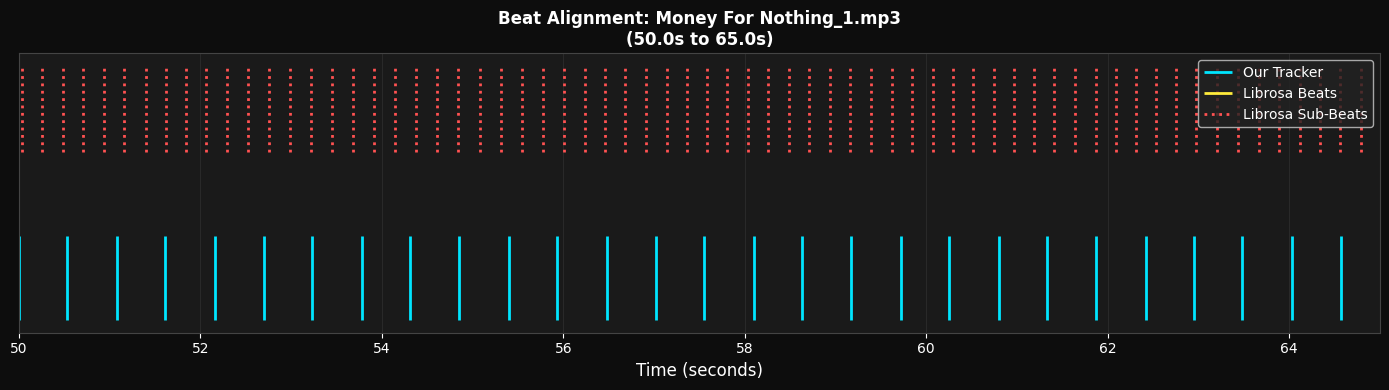

In [ ]:
import matplotlib.pyplot as plt

def plot_beats_comparison(results, song_name, start_time, end_time):
    # Find the exact key in the dictionary
    matching_keys = [k for k in results.keys() if song_name.lower() in k.lower()]
    if not matching_keys:
        print(f"Could not find a song matching '{song_name}'")
        return
        
    full_song_name = matching_keys[0]
    data = results[full_song_name]
    
    # Extract beats
    our_beats = data['our_beats']
    lib_beats = data['librosa_beats']
    lib_sub_beats = data['librosa_sub_beats']
    
    # Filter beats within the requested time window
    our_win = our_beats[(our_beats >= start_time) & (our_beats <= end_time)]
    lib_win = lib_beats[(lib_beats >= start_time) & (lib_beats <= end_time)]
    sub_win = lib_sub_beats[(lib_sub_beats >= start_time) & (lib_sub_beats <= end_time)]
    
    # Setup the plot
    plt.figure(figsize=(14, 4), facecolor='#0d0d0d')
    ax = plt.gca()
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    for sp in ax.spines.values(): sp.set_edgecolor('#444')
    ax.grid(True, alpha=0.1)
    
    # Plot beats as vertical lines stacked on top of each other
    ax.vlines(our_win, ymin=0.00, ymax=0.33, color='#00e5ff', label='Our Tracker', linewidth=2)
    ax.vlines(lib_win, ymin=0.33, ymax=0.66, color='#ffeb3b', label='Librosa Beats', linewidth=2)
    ax.vlines(sub_win, ymin=0.66, ymax=1.00, color='#ff5252', label='Librosa Sub-Beats', linewidth=2, linestyle=':')
    
    ax.set_yticks([])
    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_xlim(start_time, end_time)
    ax.set_title(f"Beat Alignment: {full_song_name}\n({start_time}s to {end_time}s)", color='white', fontweight='bold')
    
    # Deduplicate legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), facecolor='#222', labelcolor='white', loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Run it for Palladium from 30 to 45 seconds!
plot_beats_comparison(results, 'Money For Nothing_1', 50.0, 65.0)


In [ ]:
import pickle
import os

# Define the save path inside your librosa results folder
save_path = os.path.join(os.path.abspath('.'), 'librosa results', 'full_benchmark_results.pkl')

# Save the dictionary
with open(save_path, 'wb') as f:
    pickle.dump(results, f)

print(f"✅ Full benchmark results saved to: {save_path}")

✅ Full benchmark results saved to: c:\Users\Users\Desktop\vialactée\vialactee\playground\BeatTracking_Evaluation\librosa results\full_benchmark_results.pkl
